In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(f"Training sample :\n{train_data[0]}")
print(f"Training labels :\n{train_labels[0]}")

Training sample :
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1 

In [ ]:
train_data[0].shape, train_labels[0].shape

((28, 28), ())

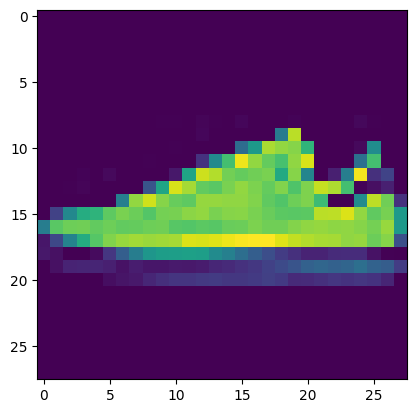

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(train_data[6])

In [ ]:
train_labels[6]

np.uint8(7)

In [ ]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
len(class_names)

10

Text(0.5, 1.0, 'Sandal')

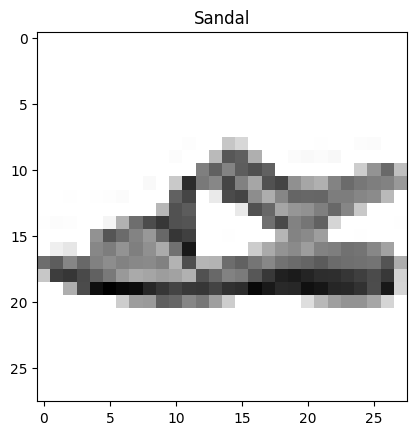

In [ ]:
index_of_choice = 43
plt.imshow(train_data[index_of_choice], cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

In [ ]:
import numpy as np

sandal_indexes = np.where(train_labels == 5)[0]

sandal_indexes[:10]

array([ 8,  9, 12, 13, 30, 36, 43, 60, 62, 63])

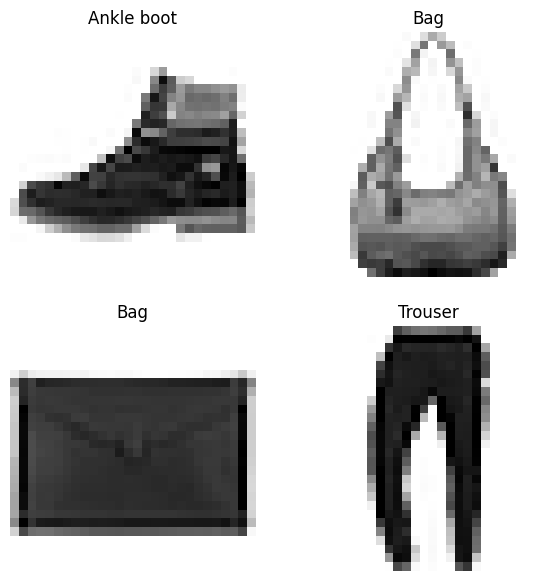

In [ ]:
import random
plt.figure(figsize=(7, 7))
for i in range(4):
  ax = plt.subplot(2, 2, i+1)
  rand_index = random.choice(range(len(train_data)))
  plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
  plt.title(class_names[train_labels[rand_index]])
  plt.axis(False)

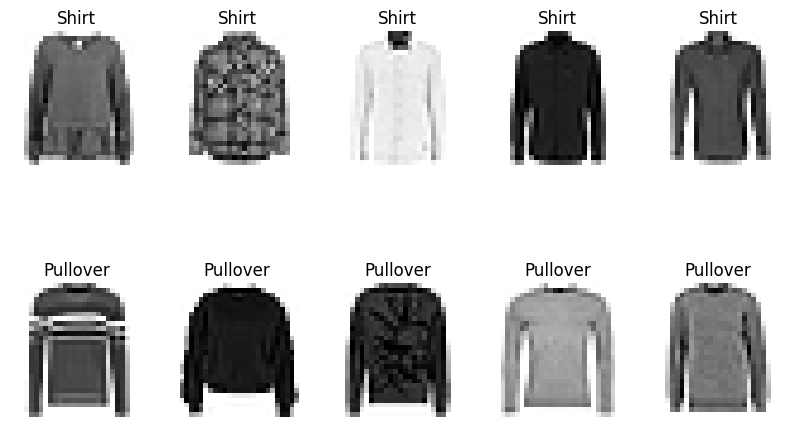

In [ ]:
shirt_indexes = np.where(train_labels == 6)[0]
pullover_indexes = np.where(train_labels == 2)[0]

plt.figure(figsize=(10, 6))

for i in range(5):
    idx = shirt_indexes[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_data[idx], cmap=plt.cm.binary)
    plt.title("Shirt")
    plt.axis("off")

for i in range(5):
    idx = pullover_indexes[i]
    plt.subplot(2, 5, i + 6)
    plt.imshow(train_data[idx], cmap=plt.cm.binary)
    plt.title("Pullover")
    plt.axis("off")

plt.show()

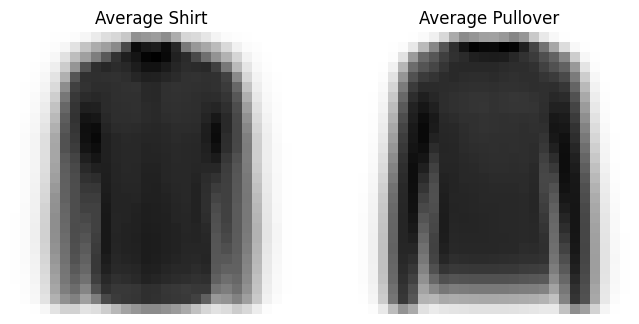

In [ ]:
shirt_mean = train_data[train_labels == 6].mean(axis=0)
pullover_mean = train_data[train_labels == 2].mean(axis=0)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(shirt_mean, cmap=plt.cm.binary)
plt.title("Average Shirt")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pullover_mean, cmap=plt.cm.binary)
plt.title("Average Pullover")
plt.axis("off")

plt.show()

## Building a multi-class classification model  

Input shape = 28 x 28 (shape of image)

Output shape = 10 (one per class of colthing)

Loss Function = tf.keras.losses.CategoricalCrossEntropy()  

--If your labels are one-hot encoded, use CategoricalEntropy()  
--If your labels are integer form use SparseCrossEntropy()  

Output Layer Activation = Softmax (not Sigmoid)  


In [ ]:
flatten_model = tf.keras.Sequential([tf.keras.layers.Flatten(input_shape=(28, 28))])
flatten_model.output_shape

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


(None, 784)

In [ ]:
28 * 28

784

In [ ]:
train_labels[0]

np.uint8(9)

In [ ]:
tf.one_hot(train_labels[:5], depth=10)

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)>

In [ ]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model_1.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
non_norm_history = model_1.fit(
    train_data,
    train_labels,
    epochs=10,
    validation_data=(test_data, test_labels)
    )


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.1077 - loss: 2.3996 - val_accuracy: 0.1372 - val_loss: 2.2527
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1765 - loss: 2.0554 - val_accuracy: 0.2517 - val_loss: 1.7840
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.2674 - loss: 1.7175 - val_accuracy: 0.2821 - val_loss: 1.6739
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2822 - loss: 1.6559 - val_accuracy: 0.2836 - val_loss: 1.6347
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2832 - loss: 1.6264 - val_accuracy: 0.2829 - val_loss: 1.6174
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.2814 - loss: 1.6097 - val_accuracy: 0.2823 - val_loss: 1.6054
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2846 - loss: 1.5998 - val_accuracy: 0.2937 - val_loss: 1.5994
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2924 - loss: 1.5922 -

In [ ]:
#Same as above
tf.random.set_seed(42)

model_1_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model_1_2.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
non_norm_history = model_1_2.fit(
    train_data,
    tf.one_hot(train_labels, depth=10),
    epochs=10,
    validation_data=(test_data, tf.one_hot(test_labels, depth=10))
    )


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.1185 - loss: 2.4923 - val_accuracy: 0.1637 - val_loss: 2.1730
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.1780 - loss: 2.1172 - val_accuracy: 0.2175 - val_loss: 2.0539
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2297 - loss: 1.9165 - val_accuracy: 0.2777 - val_loss: 1.7581
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2641 - loss: 1.7206 - val_accuracy: 0.2513 - val_loss: 1.6971
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2587 - loss: 1.6724 - val_accuracy: 0.2983 - val_loss: 1.6627
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3131 - loss: 1.6385 - val_accuracy: 0.3214 - val_loss: 1.6182
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3382 - loss: 1.6059 - val_accuracy: 0.3463 - val_loss: 1.5975
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.3708 - loss: 1.5542 - 

In [ ]:
#Check the model summary
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

In [ ]:
# Check the min and max values of the train data
train_data.min(), train_data.max()

(np.uint8(0), np.uint8(255))

Neural networks prefer data to be scaled.

In [ ]:
train_data_norm = train_data / 255.0
test_data_norm = test_data / 255.0

In [ ]:
train_data_norm.min(), train_data_norm.max()

(np.float64(0.0), np.float64(1.0))

In [ ]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model_2.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
norm_history = model_2.fit(
    train_data_norm,
    train_labels,
    epochs=10,
    validation_data=(test_data_norm, test_labels)
    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5973 - loss: 1.1267 - val_accuracy: 0.7281 - val_loss: 0.7876
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7561 - loss: 0.6927 - val_accuracy: 0.7663 - val_loss: 0.6697
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7852 - loss: 0.6074 - val_accuracy: 0.7892 - val_loss: 0.6152
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8033 - loss: 0.5665 - val_accuracy: 0.8014 - val_loss: 0.5833
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8112 - loss: 0.5453 - val_accuracy: 0.8040 - val_loss: 0.5665
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8163 - loss: 0.5329 - val_accuracy: 0.8062 - val_loss: 0.5624
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8190 - loss: 0.5247 - val_accuracy: 0.8080 - val_loss: 0.5571
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8207 - loss: 0.5185 - 

☝ Scaling pixel values from 0–255 to 0–1 helps the neural network learn faster and more stably.

<Axes: title={'center': 'Normalized data'}>

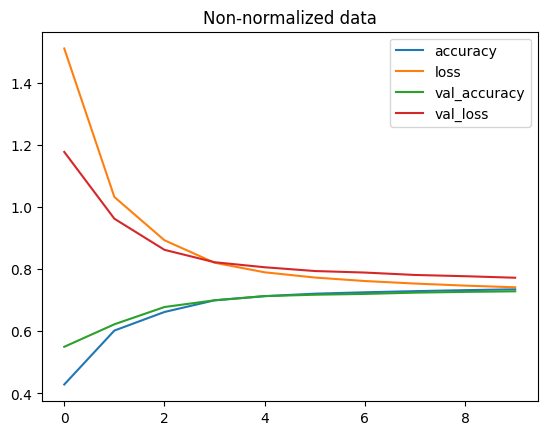

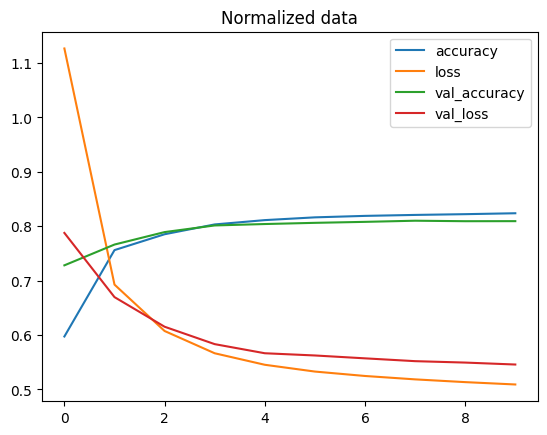

In [ ]:
import pandas as pd

# non-normalized loss curves
pd.DataFrame(non_norm_history.history).plot(title="Non-normalized data")

#normalized data loss curves
pd.DataFrame(norm_history.history).plot(title="Normalized data")


⛏ **Note :** The model with even *slightly* different data can produce *dramaticly* different results.So when you've comparing models, it's important to make sure you're comparing them on the same criteria (e.g. same architecture but different data or same data but different architecture).

## Finding the ideal learning rate

In [ ]:
tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])
model_3.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10**(epoch/20))

find_lr_history = model_3.fit(
    train_data_norm,
    train_labels,
    epochs=40,
    validation_data=(test_data_norm, test_labels),
    callbacks=[lr_scheduler]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5864 - loss: 1.0647 - val_accuracy: 0.7287 - val_loss: 0.7665 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7520 - loss: 0.7076 - val_accuracy: 0.7542 - val_loss: 0.6942 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7692 - loss: 0.6564 - val_accuracy: 0.7642 - val_loss: 0.6684 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7783 - loss: 0.6317 - val_accuracy: 0.7710 - val_loss: 0.6525 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7831 - loss: 0.6174 - val_accuracy: 0.7747 - val_loss: 0.6404 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7855 - loss: 0.6085 - val_accuracy: 0.7788 - val_loss: 0.6306 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7878 - l

Text(0, 0.5, 'loss')

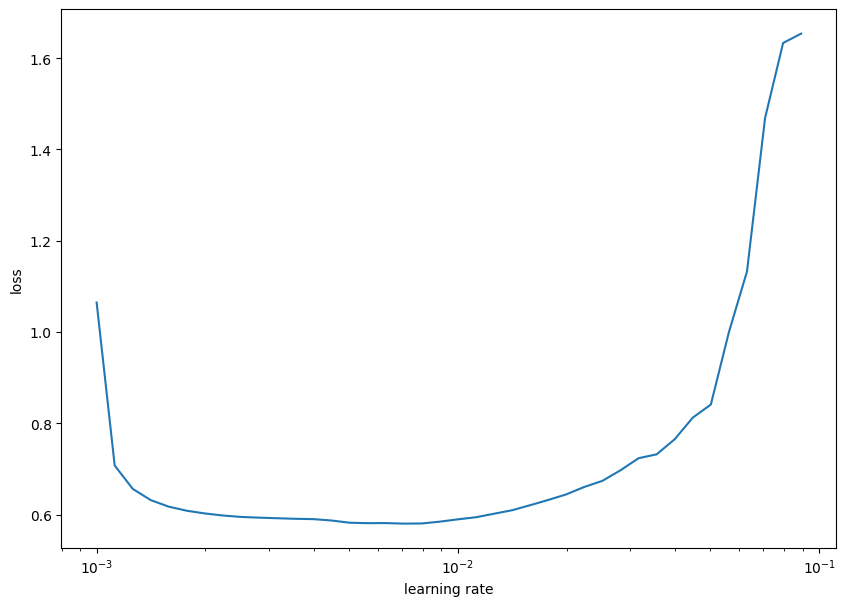

In [ ]:
#Plot the learning rate decay curve
lrs = 1e-3 * (10 ** (tf.range(40) / 20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, find_lr_history.history["loss"])
plt.xlabel("learning rate")
plt.ylabel("loss")

In [ ]:
tf.random.set_seed(42)

model_4 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])
model_4.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

history_4 = model_4.fit(
    train_data_norm,
    train_labels,
    epochs=40,
    validation_data=(test_data_norm, test_labels)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6156 - loss: 1.1209 - val_accuracy: 0.7512 - val_loss: 0.7348
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7645 - loss: 0.6686 - val_accuracy: 0.7754 - val_loss: 0.6338
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7847 - loss: 0.6040 - val_accuracy: 0.7851 - val_loss: 0.6036
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7943 - loss: 0.5743 - val_accuracy: 0.7918 - val_loss: 0.5866
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8009 - loss: 0.5574 - val_accuracy: 0.7969 - val_loss: 0.5769
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8058 - loss: 0.5462 - val_accuracy: 0.7975 - val_loss: 0.5729
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8086 - loss: 0.5381 - val_accuracy: 0.8018 - val_loss: 0.5667
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8104 - loss: 0.5321 - 

## Evaluating our multi-class classification model we could:
* Evaluate its performance using other classification metrics (such as a confusion matrix)  
* Asses some of its predictions (through visualizations)  
* Improve its results (by training it for longer or changing the archietcture)  
* Save and export it for use in an application  

Let's go through the top 2 ...


## Create a confusion matrix

In [ ]:
import itertools
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=10):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    n_classes = cm.shape[0]

    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)

    if classes:
        labels = classes
    else:
        labels = np.arange(n_classes)

    ax.set(
        title="Confusion Matrix",
        xlabel="Predicted Label",
        ylabel="True Label",
        xticks=np.arange(n_classes),
        yticks=np.arange(n_classes),
        xticklabels=labels,
        yticklabels=labels
    )

    ax.xaxis.set_label_position("bottom")
    ax.xaxis.tick_bottom()

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    ax.yaxis.label.set_size(text_size)
    ax.xaxis.label.set_size(text_size)
    ax.title.set_size(text_size + 2)

    threshold = (cm.max() + cm.min()) / 2.

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j, i,
            f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)",
            horizontalalignment="center",
            color="white" if cm[i, j] > threshold else "black",
            size=text_size
        )

    plt.tight_layout()
    plt.show()

In [ ]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
y_probs[0], tf.argmax(y_probs[0]), class_names[tf.argmax(y_probs[0])]

(array([3.1128704e-09, 5.9955834e-12, 4.6035344e-13, 2.8986702e-17,
        7.3051093e-10, 2.5794306e-01, 4.3518935e-09, 8.4452994e-02,
        7.6715685e-03, 6.4993238e-01], dtype=float32),
 <tf.Tensor: shape=(), dtype=int64, numpy=9>,
 'Ankle boot')

In [ ]:
y_probs = model_4.predict(test_data_norm)
y_probs[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[3.1128704e-09, 5.9955834e-12, 4.6035344e-13, 2.8986702e-17,
        7.3051093e-10, 2.5794306e-01, 4.3518935e-09, 8.4452994e-02,
        7.6715685e-03, 6.4993238e-01],
       [6.2223535e-08, 2.4102176e-12, 9.9026728e-01, 1.7251774e-05,
        7.8220544e-03, 1.3953030e-22, 1.8879963e-03, 0.0000000e+00,
        5.3018503e-06, 2.6964291e-23],
       [1.3233999e-04, 9.9931592e-01, 2.9806017e-08, 3.0496120e-04,
        1.1891254e-04, 4.7136033e-28, 1.2585399e-04, 6.6711999e-21,
        1.9515915e-06, 5.4114566e-20],
       [4.3322070e-05, 9.9957365e-01, 6.5931558e-09, 2.9732217e-04,
        3.3698969e-05, 6.9176367e-32, 5.1955998e-05, 1.5231496e-24,
        7.7350485e-08, 3.5911261e-23],
       [8.1527054e-02, 3.8848048e-05, 4.0976498e-01, 2.2752808e-02,
        1.9050283e-02, 7.5144285e-08, 4.6139979e-01, 6.3126198e-15,
        5.4661711e-03, 2.0383766e-10]], dtype=float32)

In [ ]:
# Convert all of the prediction probabilities into integers
y_preds = y_probs.argmax(axis=1)
y_preds[:10]

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [ ]:
test_labels[:10]

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7], dtype=uint8)

⏰ **Note :**  Remember to make predictions on the same kind of data your model was trained on (e.g. if your model was trained on normalized data, you'll want to make predictions on normalized data).

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true=test_labels, y_pred=y_preds)

array([[729,   5,  18, 106,   4,   4, 119,   0,  15,   0],
       [  3, 937,   0,  41,   9,   0,   8,   0,   2,   0],
       [ 12,   1, 756,  29, 114,   0,  82,   0,   6,   0],
       [ 24,  15,  24, 882,  29,   0,  21,   0,   5,   0],
       [  0,   1, 206,  46, 691,   0,  52,   0,   4,   0],
       [  1,   0,   0,   0,   0, 906,   0,  47,  11,  35],
       [128,  10, 206,  71, 114,   2, 459,   0,  10,   0],
       [  0,   0,   0,   0,   0,  41,   0, 927,   0,  32],
       [  6,   3,   8,   6,   3,  14,  40,   5, 914,   1],
       [  0,   0,   0,   0,   0,  36,   0,  67,   2, 895]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


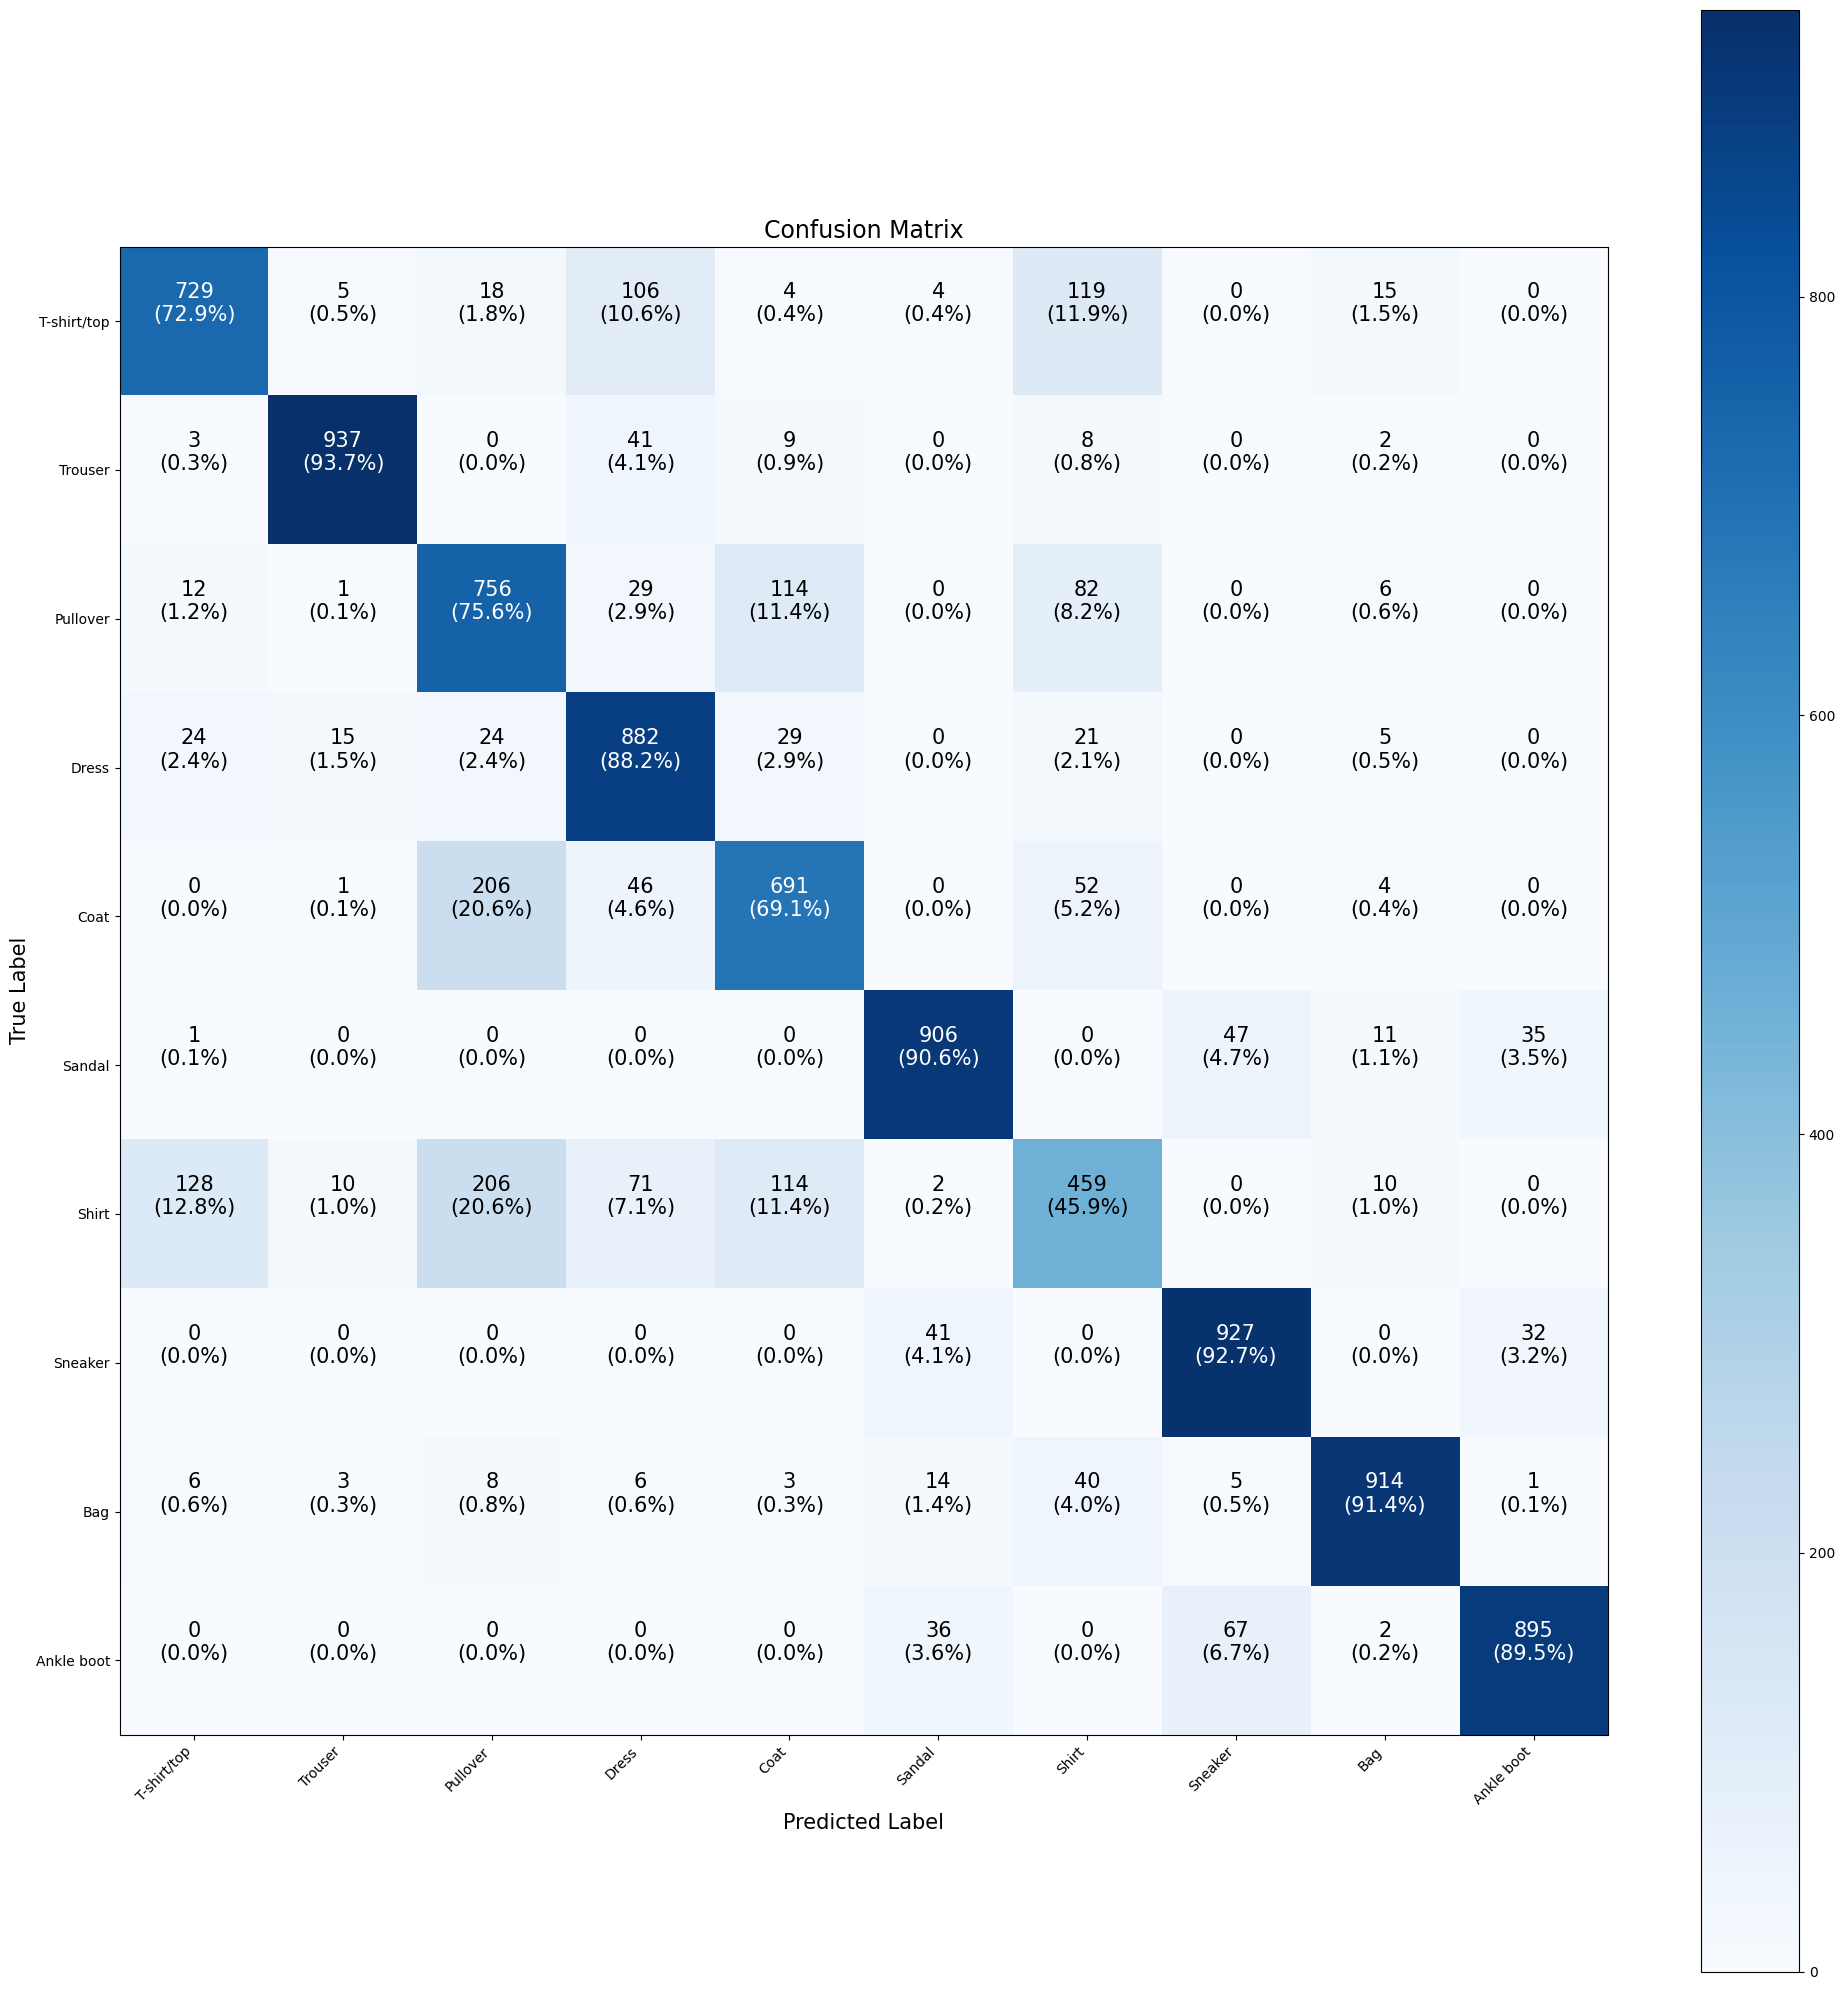

In [ ]:
make_confusion_matrix(y_true=test_labels,
                      y_pred=model_4.predict(test_data_norm).argmax(axis=1), #y_preds
                      classes=class_names,
                      figsize=(20, 20),
                      text_size=15)

How about we create a fun little for :  

-Plot a random image  
-Make a prediction on said image  
-Label the plot with truth label & the predicted label  

In [ ]:
import random

def plot_random_image(model, images, true_labels, classes):
  """
  Picks a andom image, plots it and labels it with a predcition and truth label.
  """
  i = random.randint(0, len(images))

  target_image = images[i]
  pred_probs = model.predict(target_image.reshape(1, 28, 28))
  pred_label = classes[pred_probs.argmax()]
  true_label = classes[true_labels[i]]

  plt.imshow(target_image, cmap=plt.cm.binary)

  if pred_label == true_label:
    color = "green"
  else:
    color="red"

  plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(pred_label,
                                                   100 * tf.reduce_max(pred_probs),
                                                   true_label),
             color=color)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


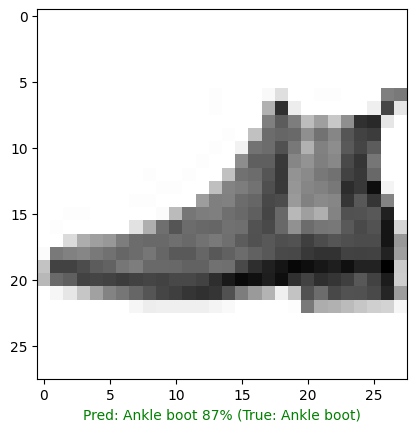

In [ ]:
plot_random_image(model=model_4,
                  images=test_data_norm,
                  true_labels=test_labels,
                  classes=class_names)

## What pattern is our model learning??

In [ ]:
# Find the layers of our model
model_4.layers

[<Flatten name=flatten_6, built=True>,
 <Dense name=dense_15, built=True>,
 <Dense name=dense_16, built=True>,
 <Dense name=dense_17, built=True>]

In [ ]:
model_4.layers[1]

<Dense name=dense_15, built=True>

In [ ]:
# Get the patterns of a layer in our network
weigths, biases = model_4.layers[1].get_weights()
weigths, weigths.shape

(array([[ 1.1213014 ,  0.53092116, -0.37699863, -0.0152587 ],
        [ 0.8166348 , -1.0310068 , -1.6506344 , -0.33476743],
        [-0.44257978, -1.9260707 , -0.02115876, -1.1848063 ],
        ...,
        [ 0.2566018 , -0.48755196,  1.3431237 ,  0.7753751 ],
        [-0.3394512 ,  0.25033802,  1.2269214 ,  0.34008613],
        [ 0.4457399 , -0.48063514,  1.46945   , -0.30833396]],
       dtype=float32),
 (784, 4))

 🦤 glorot_uniform is the default weight initializer for Dense layers.   
It initializes kernel weights with small random values based on the layer’s input and output size.  

In [ ]:
model_4.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

#### Now let's chcek out the bias vector

In [ ]:
biases, biases.shape

(array([ 1.9630238 , -0.20625134,  1.6075389 ,  2.1101477 ], dtype=float32),
 (4,))

Every neuron has a bias vector.Each of these is paired with a weights matrix.  

The bias vector get initialized as zeros (at least in the case of a TnesorFlow Dense layer).  

The bias vector dictates how much the pattern within the corresponding weights matrix should influence the next layer.  





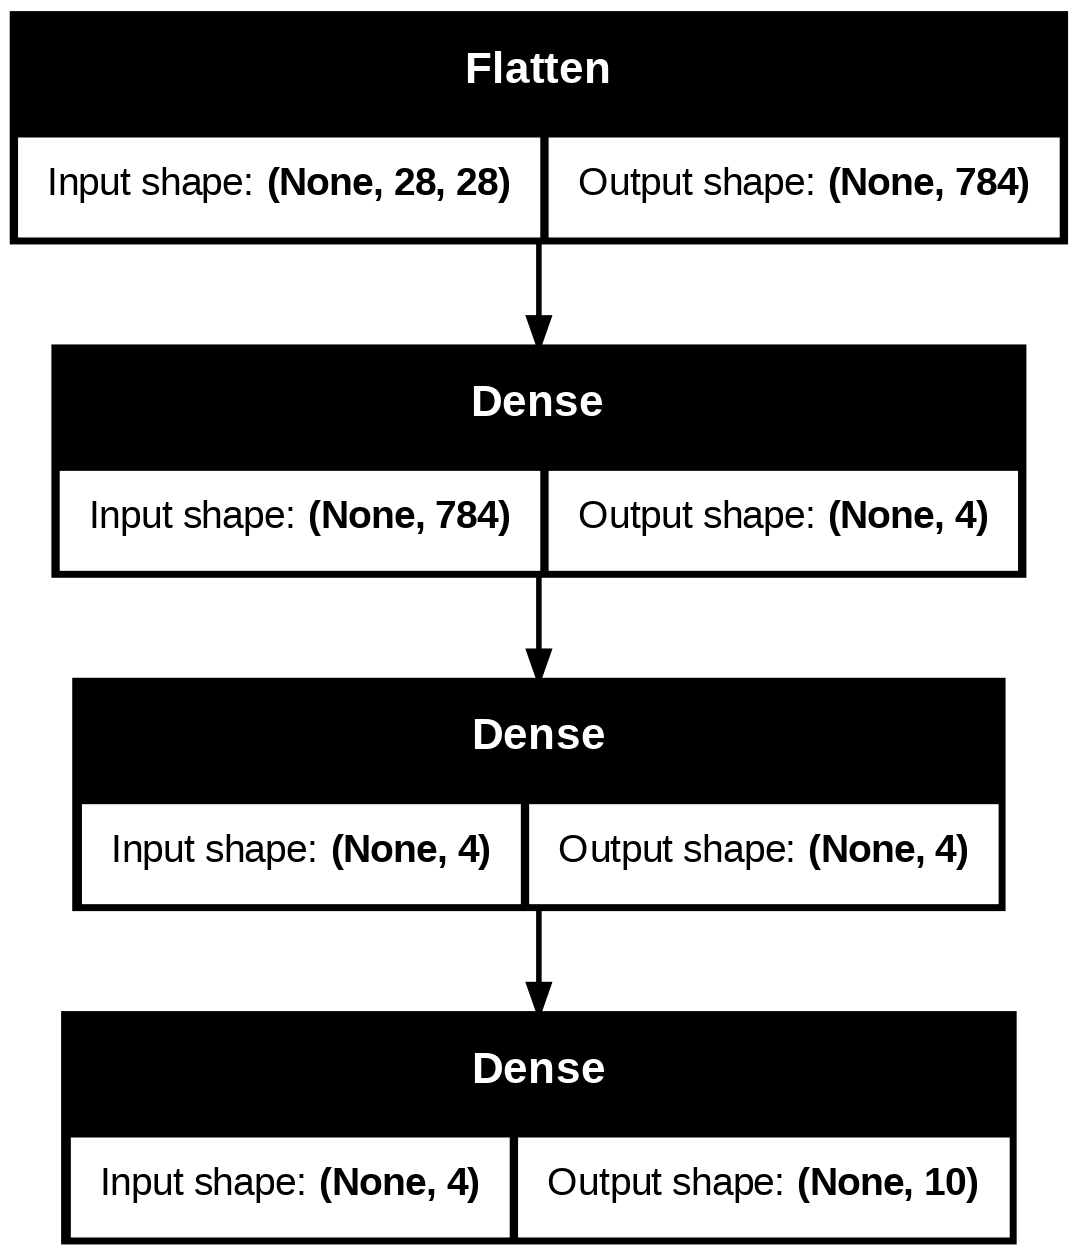

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model=model_4, show_shapes=True)

https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/README.md#-02-neural-network-classification-with-tensorflow-exercises